# Does Visual-Language Context Improve Action Recognition?
## Qwen2-VL 7B — Multi-Dataset Evaluation Framework

**Three conditions:**
- **Condition A** — Frame only (zero-shot baseline)
- **Condition B** — Frame + correct label (oracle upper bound)
- **Condition C** — Frame + wrong label (noise injection control)

**Datasets supported:**
| Dataset | Classes | Format | Difficulty |
|---------|---------|--------|------------|
| UCF-101 | 101 | .avi | Low — scene-based actions |
| Kinetics-400 Mini | 200 | .mp4 | Medium — diverse actions |
| Something-Something v2 | 174 | .webm | High — temporal reasoning required |

**To switch dataset:** change `ACTIVE_DATASET` in the Config cell below.

## 1. Setup

In [1]:
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

install('transformers>=4.37.0')
install('accelerate')
install('qwen-vl-utils')
install('opencv-python-headless')
for pkg in ['Pillow', 'pandas', 'numpy', 'matplotlib', 'scipy', 'tqdm']:
    install(pkg)
print('Done')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 49.9 MB/s eta 0:00:00
Done


In [2]:
import os, random, json
import numpy as np
import pandas as pd
import torch
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from pathlib import Path
from scipy.stats import chi2
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

Device: cuda
GPU : Tesla T4
VRAM: 15.6 GB


## 2. Config — Change Dataset Here

In [3]:
# ============================================================
# SET ACTIVE DATASET HERE — change this line only
# Options: 'ucf101' | 'kinetics400' | 'ssv2'
ACTIVE_DATASET = 'ssv2'
# ============================================================

DATASET_CONFIGS = {
    'ucf101': {
        'name': 'UCF-101',
        'root': '/kaggle/input/datasets/matthewjansen/ucf101-action-recognition/train',
        'ext': '*.avi',
        'n_per_class': 2,
        'difficulty': 'Low — scene-based actions'
    },
    'kinetics400': {
        'name': 'Kinetics-400 Mini',
        'root': '/kaggle/input/datasets/duckdai/kinetics400-mini/kinetics400_mini/train',
        'ext': '*.mp4',
        'n_per_class': 2,
        'difficulty': 'Medium — diverse actions'
    },
    'ssv2': {
        'name': 'Something-Something v2',
        'root': '/kaggle/input/datasets/ipythonx/ssv2test',
        'ext': '*.webm',
        'n_per_class': 2,
        'difficulty': 'High — temporal reasoning required'
    }
}

CFG = DATASET_CONFIGS[ACTIVE_DATASET]
DATASET_ROOT = Path(CFG['root'])
VIDEO_EXT = CFG['ext']
N_PER_CLASS = CFG['n_per_class']
DATASET_NAME = CFG['name']
OUTPUT_PREFIX = f'/kaggle/working/{ACTIVE_DATASET}'

print(f'Active dataset : {DATASET_NAME}')
print(f'Root           : {DATASET_ROOT}')
print(f'Video format   : {VIDEO_EXT}')
print(f'Difficulty     : {CFG["difficulty"]}')
print(f'Output prefix  : {OUTPUT_PREFIX}')

Active dataset : Something-Something v2
Root           : /kaggle/input/datasets/ipythonx/ssv2test
Video format   : *.webm
Difficulty     : High — temporal reasoning required
Output prefix  : /kaggle/working/ssv2


## 3. Dataset Loader

In [4]:
# Discover classes from folder names
ALL_CLASSES = sorted([d.name for d in DATASET_ROOT.iterdir() if d.is_dir()])
print(f'Total action classes : {len(ALL_CLASSES)}')
print('Sample classes       :', ALL_CLASSES[:5])

Total action classes : 174
Sample classes       : ['Approaching something with your camera', 'Attaching something to something', 'Bending something so that it deforms', 'Bending something until it breaks', 'Burying something in something']


In [5]:
def extract_middle_frame(video_path):
    """
    Extract the middle frame from a video as a PIL Image.
    Works with .avi, .mp4, .webm — OpenCV handles all three.
    Middle frame chosen to capture peak action, avoid intros/outros.
    """
    cap = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total == 0:
        cap.release()
        return None
    cap.set(cv2.CAP_PROP_POS_FRAMES, total // 2)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        return None
    return Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))


def build_sample_list(root, ext, n_per_class, seed=42):
    """
    Build balanced sample list: n_per_class videos per class.
    Works for any dataset with class-named folders.
    """
    random.seed(seed)
    samples = []
    for class_dir in sorted(root.iterdir()):
        if not class_dir.is_dir():
            continue
        videos = list(class_dir.glob(ext))
        if not videos:
            continue
        selected = random.sample(videos, min(n_per_class, len(videos)))
        for v in selected:
            samples.append((v, class_dir.name))
    random.shuffle(samples)
    return samples


def get_wrong_label(correct_label, all_classes):
    pool = [c for c in all_classes if c != correct_label]
    return random.choice(pool)


samples = build_sample_list(DATASET_ROOT, VIDEO_EXT, N_PER_CLASS)
print(f'Total samples: {len(samples)}')
print('Example      :', samples[0])

Total samples: 348
Example      : (PosixPath('/kaggle/input/datasets/ipythonx/ssv2test/Burying something in something/90498.webm'), 'Burying something in something')


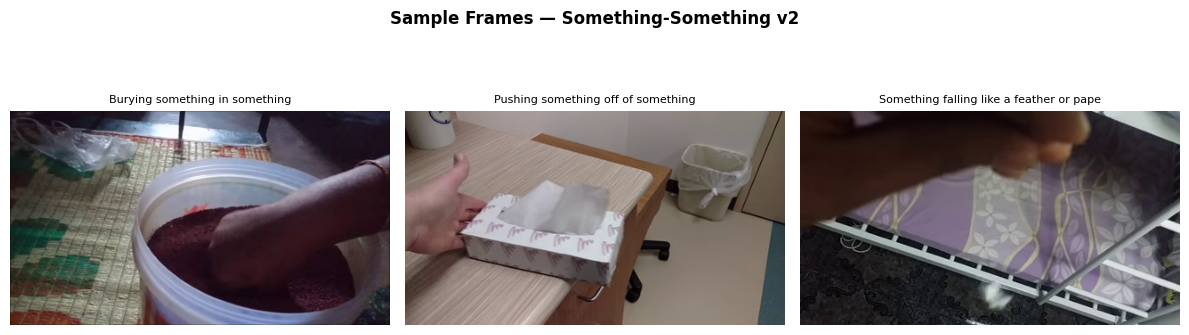

In [6]:
# Sanity check — show 3 sample frames
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, ax in enumerate(axes):
    video_path, label = samples[i]
    frame = extract_middle_frame(video_path)
    if frame:
        ax.imshow(frame)
        ax.set_title(label[:40], fontsize=8)
    ax.axis('off')
plt.suptitle(f'Sample Frames — {DATASET_NAME}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_PREFIX}_sample_frames.png', dpi=100)
plt.show()

## 4. Qwen2-VL 7B — Three Condition Inference

In [7]:
class Qwen2VLEvaluator:
    """
    Qwen2-VL 7B inference across three evaluation conditions.

    A: zero-shot   — raw visual understanding, no context
    B: oracle      — ground truth label as context (upper bound)
    C: noise       — wrong label as context (proves genuine context use)

    Note on Something-Something v2:
    SSv2 actions are inherently temporal (e.g. 'moving something up').
    A single frame cannot disambiguate many classes — condition B/C
    effect should be strongest on this dataset.
    """
    def __init__(self, model_name='Qwen/Qwen2-VL-7B-Instruct'):
        print(f'Loading {model_name}...')
        self.processor = AutoProcessor.from_pretrained(
            model_name,
            min_pixels=256*28*28,
            max_pixels=1280*28*28
        )
        self.model = Qwen2VLForConditionalGeneration.from_pretrained(
            model_name,
            torch_dtype=torch.float16,
            device_map='auto'
        )
        self.model.eval()
        print('Qwen2-VL 7B ready')

    def _prompt(self, condition, gt_label=None, wrong_label=None):
        class_list = ', '.join(ALL_CLASSES)
        if condition == 'A':
            return (
                f'You are an action recognition system. '
                f'Possible action classes: {class_list}. '
                f'What action is being performed in this image? '
                f'Return only the single class name from the list above. No explanation.'
            )
        elif condition == 'B':
            return (
                f'A reference system identified the action as: {gt_label}. '
                f'Using this context and the image, select the correct action from: {class_list}. '
                f'Return only the single class name. No explanation.'
            )
        elif condition == 'C':
            return (
                f'A reference system identified the action as: {wrong_label}. '
                f'Using this context and the image, select the correct action from: {class_list}. '
                f'Return only the single class name. No explanation.'
            )

    def predict(self, image, condition, gt_label=None, wrong_label=None):
        prompt = self._prompt(condition, gt_label, wrong_label)
        messages = [{'role': 'user', 'content': [
            {'type': 'image', 'image': image},
            {'type': 'text', 'text': prompt}
        ]}]
        text = self.processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        inputs = self.processor(
            text=[text], images=[image], return_tensors='pt'
        ).to(self.model.device)
        with torch.no_grad():
            out = self.model.generate(**inputs, max_new_tokens=50, do_sample=False)
        return self.processor.batch_decode(
            out[:, inputs.input_ids.shape[1]:], skip_special_tokens=True
        )[0].strip()


model = Qwen2VLEvaluator()

Loading Qwen/Qwen2-VL-7B-Instruct...


preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/244 [00:00<?, ?B/s]

Qwen2-VL 7B ready


## 5. Evaluation Framework

In [8]:
class ResultsTracker:
    def __init__(self, dataset_name):
        self.dataset_name = dataset_name
        self.records = []
        self.hits = {'A': [], 'B': [], 'C': []}

    def _hit(self, predicted, ground_truth):
        pred = predicted.strip().lower()
        gt = ground_truth.strip().lower()
        return int(gt in pred or pred in gt or pred == gt)

    def add(self, video_path, gt_label, pred_A, pred_B, pred_C, wrong_label):
        hit_A = self._hit(pred_A, gt_label)
        hit_B = self._hit(pred_B, gt_label)
        hit_C = self._hit(pred_C, gt_label)
        for cond, h in [('A', hit_A), ('B', hit_B), ('C', hit_C)]:
            self.hits[cond].append(h)
        self.records.append({
            'dataset': self.dataset_name,
            'video': str(video_path.name),
            'ground_truth': gt_label,
            'pred_A': pred_A, 'pred_B': pred_B, 'pred_C': pred_C,
            'wrong_label': wrong_label,
            'hit_A': hit_A, 'hit_B': hit_B, 'hit_C': hit_C
        })

    def accuracy(self, cond):
        return np.mean(self.hits[cond]) if self.hits[cond] else 0.0

    def to_dataframe(self):
        return pd.DataFrame(self.records)

    def summary(self):
        n = len(self.records)
        a, b, c = self.accuracy('A'), self.accuracy('B'), self.accuracy('C')
        print('\n' + '='*55)
        print(f'RESULTS — Qwen2-VL 7B on {self.dataset_name}')
        print('='*55)
        print(f'Samples          : {n}')
        print(f'A  Zero-shot     : {a:.3f}')
        print(f'B  Oracle        : {b:.3f}  ({b-a:+.3f} vs A)')
        print(f'C  Noise         : {c:.3f}  ({c-a:+.3f} vs A)')
        print('='*55)


tracker = ResultsTracker(DATASET_NAME)
print('Tracker ready')

Tracker ready


## 6. Run Evaluation

In [9]:
skipped = 0

for idx, (video_path, gt_label) in enumerate(tqdm(samples, desc=f'Evaluating {DATASET_NAME}')):

    frame = extract_middle_frame(video_path)
    if frame is None:
        skipped += 1
        continue

    wrong_label = get_wrong_label(gt_label, ALL_CLASSES)

    pred_A = model.predict(frame, 'A')
    pred_B = model.predict(frame, 'B', gt_label=gt_label)
    pred_C = model.predict(frame, 'C', wrong_label=wrong_label)

    tracker.add(video_path, gt_label, pred_A, pred_B, pred_C, wrong_label)

    if (idx + 1) % 25 == 0:
        tracker.to_dataframe().to_csv(f'{OUTPUT_PREFIX}_checkpoint.csv', index=False)
        print(f'[{idx+1}/{len(samples)}] A={tracker.accuracy("A"):.3f} B={tracker.accuracy("B"):.3f} C={tracker.accuracy("C"):.3f}')

results_df = tracker.to_dataframe()
results_df.to_csv(f'{OUTPUT_PREFIX}_results.csv', index=False)
print(f'\nDone. Skipped {skipped} unreadable videos.')
tracker.summary()

Evaluating Something-Something v2:   7%|▋         | 25/348 [03:25<46:58,  8.73s/it]

[25/348] A=0.240 B=0.800 C=0.160


Evaluating Something-Something v2:  14%|█▍        | 50/348 [07:02<43:33,  8.77s/it]

[50/348] A=0.140 B=0.760 C=0.080


Evaluating Something-Something v2:  22%|██▏       | 75/348 [10:38<39:12,  8.62s/it]

...

[300/348] A=0.080 B=0.810 C=0.043


Evaluating Something-Something v2:  93%|█████████▎| 325/348 [46:49<03:09,  8.22s/it]

[325/348] A=0.074 B=0.806 C=0.040


Evaluating Something-Something v2: 100%|██████████| 348/348 [50:03<00:00,  8.63s/it]


Done. Skipped 1 unreadable videos.

RESULTS — Qwen2-VL 7B on Something-Something v2
Samples          : 347
A  Zero-shot     : 0.075
B  Oracle        : 0.804  (+0.729 vs A)
C  Noise         : 0.037  (-0.037 vs A)


## 7. Statistical Significance — McNemar Test

In [10]:
def mcnemar_test(hits_A, hits_B, label=''):
    n01 = sum(1 for a, b in zip(hits_A, hits_B) if a == 0 and b == 1)
    n10 = sum(1 for a, b in zip(hits_A, hits_B) if a == 1 and b == 0)
    if n01 + n10 == 0:
        print(f'{label}: No discordant pairs'); return
    chi2_stat = (abs(n01 - n10) - 1) ** 2 / (n01 + n10)
    p = 1 - chi2.cdf(chi2_stat, df=1)
    direction = 'B better' if n01 > n10 else 'A better'
    print(f'{label}')
    print(f'  B correct/A wrong: {n01}  |  A correct/B wrong: {n10}  |  {direction}')
    print(f'  chi2={chi2_stat:.3f}  p={p:.4f}  significant: {p < 0.05}\n')

print(f'Statistical Significance — {DATASET_NAME}')
print('='*55)
mcnemar_test(tracker.hits['A'], tracker.hits['B'], 'Oracle grounded (B) vs Zero-shot (A)')
mcnemar_test(tracker.hits['A'], tracker.hits['C'], 'Noise injection (C) vs Zero-shot (A)')
mcnemar_test(tracker.hits['B'], tracker.hits['C'], 'Oracle grounded (B) vs Noise (C)')

Statistical Significance — Something-Something v2
Oracle grounded (B) vs Zero-shot (A)
  B correct/A wrong: 253  |  A correct/B wrong: 0  |  B better
  chi2=251.004  p=0.0000  significant: True

Noise injection (C) vs Zero-shot (A)
  B correct/A wrong: 3  |  A correct/B wrong: 16  |  A better
  chi2=7.579  p=0.0059  significant: True

Oracle grounded (B) vs Noise (C)
  B correct/A wrong: 0  |  A correct/B wrong: 266  |  A better
  chi2=264.004  p=0.0000  significant: True



## 8. Visualisation

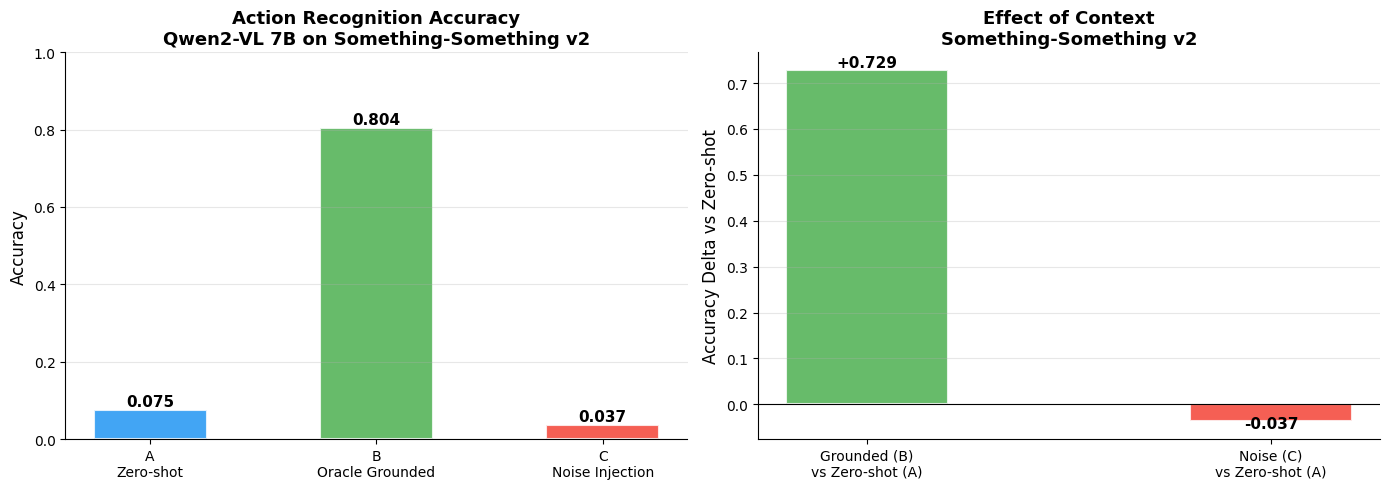

In [11]:
acc_A = tracker.accuracy('A')
acc_B = tracker.accuracy('B')
acc_C = tracker.accuracy('C')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

conds = ['A\nZero-shot', 'B\nOracle Grounded', 'C\nNoise Injection']
accs = [acc_A, acc_B, acc_C]
cols = ['#2196F3', '#4CAF50', '#F44336']
bars = axes[0].bar(conds, accs, color=cols, alpha=0.85, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title(f'Action Recognition Accuracy\nQwen2-VL 7B on {DATASET_NAME}', fontsize=13, fontweight='bold')
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{acc:.3f}', ha='center', fontweight='bold', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

deltas = [acc_B - acc_A, acc_C - acc_A]
dlabels = ['Grounded (B)\nvs Zero-shot (A)', 'Noise (C)\nvs Zero-shot (A)']
dcols = ['#4CAF50' if d >= 0 else '#F44336' for d in deltas]
bars2 = axes[1].bar(dlabels, deltas, color=dcols, alpha=0.85, edgecolor='white', linewidth=1.5, width=0.4)
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].set_ylabel('Accuracy Delta vs Zero-shot', fontsize=12)
axes[1].set_title(f'Effect of Context\n{DATASET_NAME}', fontsize=13, fontweight='bold')
for bar, d in zip(bars2, deltas):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.005 if d >= 0 else -0.015),
                f'{d:+.3f}', ha='center', fontweight='bold', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_PREFIX}_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Cross-Dataset Comparison
Run this cell after completing all three datasets. Paste your results below.

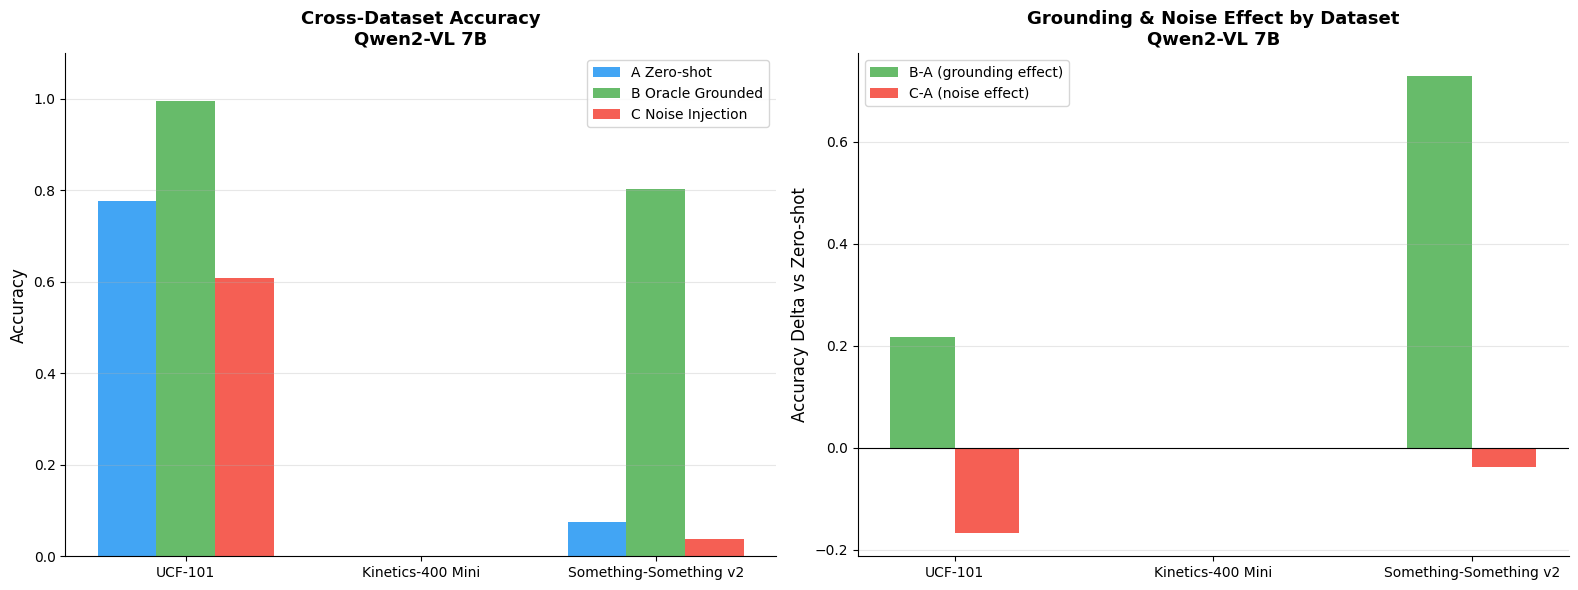


Dataset                               A        B        C      B-A      C-A
----------------------------------------------------------------------
UCF-101                           0.777    0.995    0.609    0.218   -0.168
Kinetics-400 Mini                 0.000    0.000    0.000    0.000    0.000
Something-Something v2            0.075    0.804    0.037    0.729   -0.037


In [12]:
# ── Paste your results from each dataset run here ──
all_results = {
    'UCF-101':                  {'A': 0.777, 'B': 0.995, 'C': 0.609},
    'Kinetics-400 Mini':        {'A': 0.000, 'B': 0.000, 'C': 0.000},  # fill in
    'Something-Something v2':   {'A': 0.000, 'B': 0.000, 'C': 0.000},  # fill in after this run
}

# Auto-fill current dataset result
all_results[DATASET_NAME] = {
    'A': tracker.accuracy('A'),
    'B': tracker.accuracy('B'),
    'C': tracker.accuracy('C')
}

datasets = list(all_results.keys())
x = np.arange(len(datasets))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left — accuracy per condition per dataset
vals_A = [all_results[d]['A'] for d in datasets]
vals_B = [all_results[d]['B'] for d in datasets]
vals_C = [all_results[d]['C'] for d in datasets]

axes[0].bar(x - width, vals_A, width, label='A Zero-shot',       color='#2196F3', alpha=0.85)
axes[0].bar(x,         vals_B, width, label='B Oracle Grounded', color='#4CAF50', alpha=0.85)
axes[0].bar(x + width, vals_C, width, label='C Noise Injection', color='#F44336', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(datasets, fontsize=10)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Cross-Dataset Accuracy\nQwen2-VL 7B', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right — delta B-A and C-A per dataset
delta_BA = [all_results[d]['B'] - all_results[d]['A'] for d in datasets]
delta_CA = [all_results[d]['C'] - all_results[d]['A'] for d in datasets]

axes[1].bar(x - width/2, delta_BA, width, label='B-A (grounding effect)', color='#4CAF50', alpha=0.85)
axes[1].bar(x + width/2, delta_CA, width, label='C-A (noise effect)',     color='#F44336', alpha=0.85)
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(datasets, fontsize=10)
axes[1].set_ylabel('Accuracy Delta vs Zero-shot', fontsize=12)
axes[1].set_title('Grounding & Noise Effect by Dataset\nQwen2-VL 7B', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/kaggle/working/cross_dataset_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print(f'\n{"Dataset":30} {"A":>8} {"B":>8} {"C":>8} {"B-A":>8} {"C-A":>8}')
print('-' * 70)
for d in datasets:
    r = all_results[d]
    print(f'{d:30} {r["A"]:8.3f} {r["B"]:8.3f} {r["C"]:8.3f} {r["B"]-r["A"]:8.3f} {r["C"]-r["A"]:8.3f}')

## 10. Key Findings

In [13]:
print(f'KEY FINDINGS — {DATASET_NAME}')
print('='*55)
print(f'A  Zero-shot : {acc_A:.3f}')
print(f'B  Oracle    : {acc_B:.3f}  ({acc_B-acc_A:+.3f})')
print(f'C  Noise     : {acc_C:.3f}  ({acc_C-acc_A:+.3f})')
print()

if ACTIVE_DATASET == 'ssv2':
    print('NOTE: Something-Something v2 is designed for temporal reasoning.')
    print('Many classes are visually indistinguishable from a single frame.')
    print('Lower zero-shot accuracy expected — stronger grounding effect expected.')
    print()

if acc_B > acc_A:
    print(f'FINDING 1: Oracle context IMPROVES performance on {DATASET_NAME}')
else:
    print(f'FINDING 1: Oracle context does NOT improve on {DATASET_NAME}')
    print('  Visual ambiguity may overwhelm text context on this harder dataset')
print()
if acc_C < acc_A:
    print('FINDING 2: Noise injection DEGRADES performance')
    print('  Model genuinely reads and uses text context')
else:
    print('FINDING 2: Noise injection does NOT degrade performance')
    print('  On temporally ambiguous actions, model may ignore text and guess visually')
print()
print('Framework is model-agnostic.')
print('Pixtral 12B can replace Qwen2-VL when sufficient VRAM is available.')

KEY FINDINGS — Something-Something v2
A  Zero-shot : 0.075
B  Oracle    : 0.804  (+0.729)
C  Noise     : 0.037  (-0.037)

NOTE: Something-Something v2 is designed for temporal reasoning.
Many classes are visually indistinguishable from a single frame.
Lower zero-shot accuracy expected — stronger grounding effect expected.

FINDING 1: Oracle context IMPROVES performance on Something-Something v2

FINDING 2: Noise injection DEGRADES performance
  Model genuinely reads and uses text context

Framework is model-agnostic.
Pixtral 12B can replace Qwen2-VL when sufficient VRAM is available.
